# Family Selector and Projected QP Validation Tutorial

This notebook checks two package design promises:

1. SILVA implementations can be selected by family name.
2. The projected quadratic-program layer solves real constrained fixed-point
   problems with gradients.

The shared equilibrium contract is

$$
z^\star=f_\theta(z^\star,x),
\qquad
r(z^\star,x)=f_\theta(z^\star,x)-z^\star.
$$

For the projected QP case, the state is an optimizer variable:

$$
z_i^\star
=
\arg\min_{z\in C}
\frac12 z^\top A z-b_i^\top z,
\qquad
A=L L^\top+\lambda I.
$$

The fixed-point map is

$$
T(z)=\Pi_C[z-\eta(Az-b_i)].
$$

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[5]](https://jseluis.github.io/silva-networks/paper/references/#ref-5), [[8]](https://jseluis.github.io/silva-networks/paper/references/#ref-8), [[9]](https://jseluis.github.io/silva-networks/paper/references/#ref-9), [[40]](https://jseluis.github.io/silva-networks/paper/references/#ref-40). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import (
    SILVADEQFlow,
    SILVAProjectedQPLayer,
    SolverConfig,
    available_silva_families,
    make_silva_translation_flow_batch,
    resolve_device,
    silva_deq_flow,
    silva_endpoint_error,
    silva_equilibrium_model,
    silva_family_description,
    silva_projected_qp_layer,
)

torch.manual_seed(9)
device = resolve_device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Selectable Families

The canonical public names favor SILVA-style entry points. Compatibility aliases
such as `"optical_flow_deq"` and `"constrained_quadratic_optimization"` still
resolve to the same package-native implementations.

In [3]:
for name in available_silva_families():
    print(f"{name:28s} -> {silva_family_description(name)}")

silva_layer                  -> single generalized SILVA layer with user-selected branches
silva_graph                  -> stacked SILVA graph model with per-layer operators and solvers
silva_graph_preset           -> reference graph SILVA architecture with configurable interaction modes
silva_cortex                 -> single flexible cortex-style equilibrium point with internal modules
silva_cortex_network         -> linked cortex equilibrium points with independent internal architectures
silva_image_cortex           -> convolutional-retina plus linked fast/slow cortex equilibrium points
compact_deq                  -> affine-tanh DEQ reduction inside the SILVA grammar
message_passing_deq          -> local graph/message-passing DEQ reduction
mdeq                         -> compact multiscale DEQ bridge block
multiscale_vision_deq        -> simultaneous multiresolution MDEQ image core
sequence_deq                 -> weight-shared relative-attention or trellis sequence equilibrium
impli

In [4]:
flow_from_alias = silva_equilibrium_model(
    "optical_flow_deq",
    feature_dim=2,
    hidden_dim=4,
    config=SolverConfig(solver="picard", max_iter=1, alpha=0.4),
)
qp_from_alias = silva_equilibrium_model(
    "constrained_quadratic_optimization",
    in_dim=3,
    state_dim=4,
    constraint="simplex",
    config=SolverConfig(solver="picard", max_iter=3, alpha=1.0),
)

isinstance(flow_from_alias, SILVADEQFlow), isinstance(qp_from_alias, SILVAProjectedQPLayer)

(True, True)

## Simplex Projection

The simplex constraint is

$$
\Delta_m=\{z\in\mathbb R^d:z_j\ge 0,\ \sum_jz_j=m\}.
$$

After the solve, every row should be nonnegative and should sum to `m`.

In [5]:
x = torch.randn(8, 3, device=device)
simplex_layer = silva_projected_qp_layer(
    in_dim=3,
    state_dim=4,
    constraint="simplex",
    simplex_mass=1.0,
    step_size=0.08,
    config=SolverConfig(solver="picard", max_iter=30, alpha=1.0, tol=1e-7),
).to(device)

simplex_result = simplex_layer(x, return_result=True)
simplex_energy = simplex_layer.energy(simplex_result.z, x).mean()
simplex_energy.backward()

print("shape:", tuple(simplex_result.z.shape))
print("row sums:", simplex_result.z.sum(dim=-1).detach().cpu().round(decimals=6).tolist())
print("minimum entry:", float(simplex_result.z.min().detach().cpu()))
print("projected residual:", simplex_result.residual)
print("gradient reached B:", simplex_layer.b_proj.weight.grad is not None)

shape: (8, 4)
row sums: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
minimum entry: 0.0
projected residual: 0.00085169926751405
gradient reached B: True


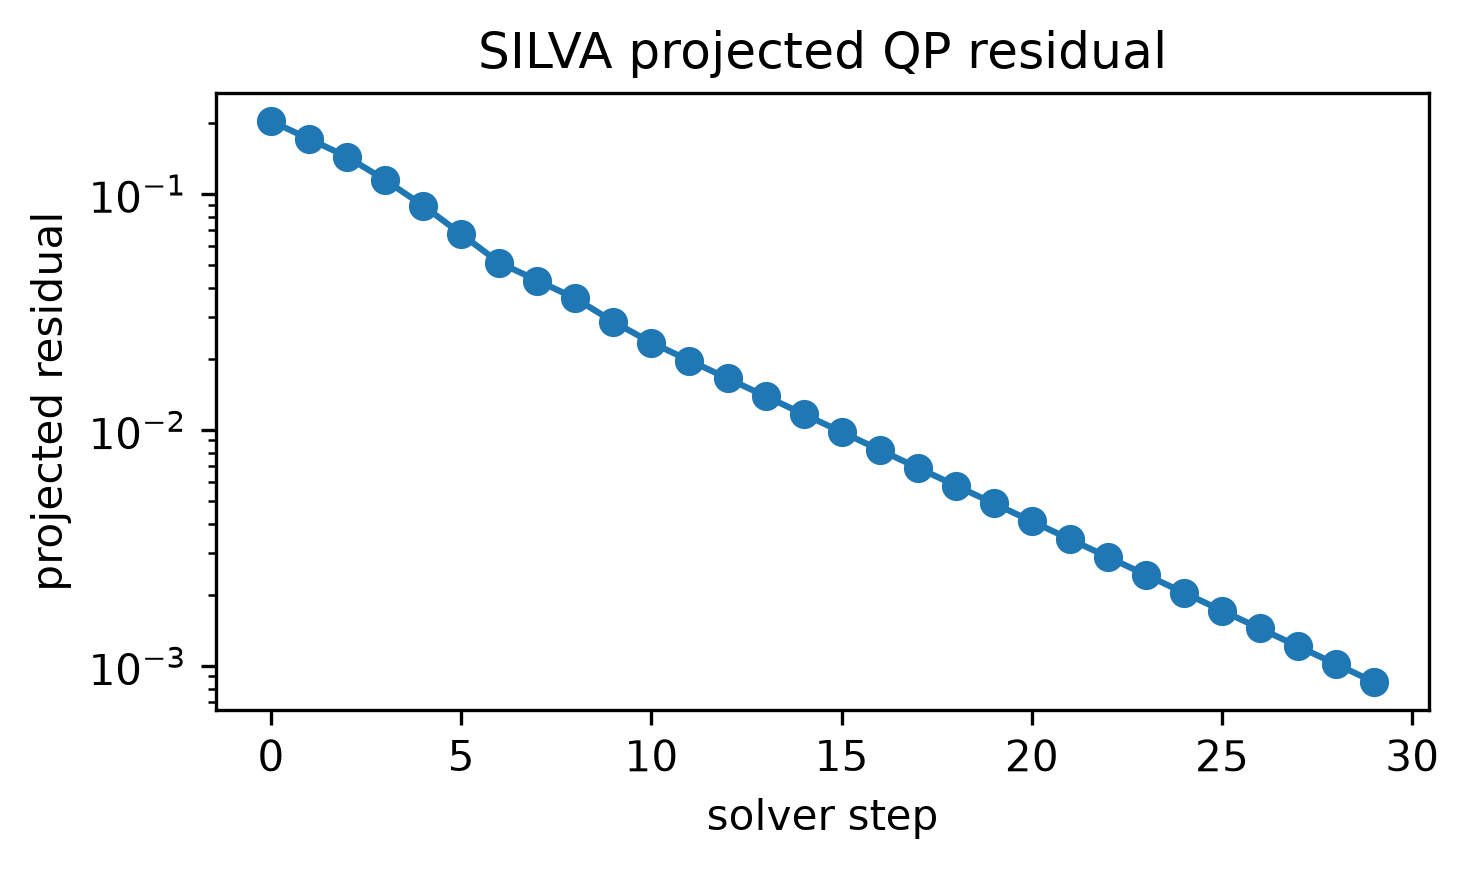

In [6]:
plt.figure(figsize=(5, 3))
plt.plot(simplex_result.residuals, marker="o")
plt.yscale("log")
plt.xlabel("solver step")
plt.ylabel("projected residual")
plt.title("SILVA projected QP residual")
plt.tight_layout()

## Box and Affine Constraints

For a box,

$$
C=[\ell,u]^d.
$$

For an affine equality,

$$
C=\{z:A_{\rm eq}z=b_{\rm eq}\}.
$$

The validation checks below verify the constraints directly from the returned
states.

In [7]:
box_layer = silva_projected_qp_layer(
    in_dim=3,
    state_dim=5,
    constraint="box",
    lower_bound=-0.25,
    upper_bound=0.25,
    step_size=0.08,
    config=SolverConfig(solver="picard", max_iter=20, alpha=1.0),
).to(device)
z_box = box_layer(x)
print(float(z_box.min().detach().cpu()), float(z_box.max().detach().cpu()))

Aeq = torch.tensor([[1.0, 1.0, 0.0]], device=device)
beq = torch.tensor([1.0], device=device)
affine_layer = silva_projected_qp_layer(
    in_dim=3,
    state_dim=3,
    constraint="affine",
    equality_matrix=Aeq,
    equality_rhs=beq,
    step_size=0.08,
    config=SolverConfig(solver="picard", max_iter=20, alpha=1.0),
).to(device)
z_affine = affine_layer(x)
print((z_affine @ Aeq.T).detach().cpu().round(decimals=6).tolist())

-0.25 0.25
[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0]]


## Flow Family Validation Check

The flow model has a different state shape, but the same solver pattern:

$$
u^\star=T_\theta(u^\star,I_1,I_2).
$$

The package-native `silva_deq_flow` name keeps the SILVA convention, while the
documentation cites RAFT for all-pairs correlation and DEQ-Flow for the
equilibrium optical-flow framing.

In [8]:
batch = make_silva_translation_flow_batch(batch_size=1, height=6, width=6, device=device)
flow_model = silva_deq_flow(
    feature_dim=2,
    hidden_dim=4,
    config=SolverConfig(solver="picard", max_iter=2, alpha=0.4),
).to(device)
flow_result = flow_model(batch.image1, batch.image2, return_result=True)
epe = silva_endpoint_error(flow_result.flow, batch.flow, batch.valid)
print(tuple(flow_result.flow.shape), float(epe.detach().cpu()), flow_result.solver_result.residual)

(1, 2, 6, 6) 1.0169347524642944 0.29829278588294983


## Citation

If this notebook or package is used, cite:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.2.2. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098
```

When the work is connected to the SILVA Networks paper, cite the paper as well.

Additional method citations:

- Deep Equilibrium Models: https://arxiv.org/abs/1909.01377
- TorchDEQ: https://github.com/locuslab/torchdeq
- RAFT: https://arxiv.org/abs/2003.12039
- Deep Equilibrium Optical Flow Estimation: https://arxiv.org/abs/2204.08442
- OptNet: https://arxiv.org/abs/1703.00443
- Differentiable Convex Optimization Layers: https://arxiv.org/abs/1910.12430
- CVXPYlayers: https://github.com/cvxpy/cvxpylayers

## From 09 Family Selector And Projected Qp to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the primal variable and any dual or auxiliary state |
| Condition | objective coefficients and constraints |
| Repeated computation | a projected, proximal, or primal-dual update |
| Required invariants | feasibility, domain projection, state shape, and optimality conditions |
| Replaceable components | objective operator, projector/proximal map, transition, solver, and readout |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [9]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**objective gap, feasibility residual, KKT residual, and gradient error**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **variable count, constraint count, conditioning, and linear-solver budget**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [10]:
notebook_reproduction_record = {
    "notebook": '09_family_selector_and_projected_qp.ipynb',
    "state": 'the primal variable and any dual or auxiliary state',
    "condition": 'objective coefficients and constraints',
    "transition": 'a projected, proximal, or primal-dual update',
    "invariants": 'feasibility, domain projection, state shape, and optimality conditions',
    "compact_metric": 'objective gap, feasibility residual, KKT residual, and gradient error',
    "scale_axis": 'variable count, constraint count, conditioning, and linear-solver budget',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '09_family_selector_and_projected_qp.ipynb',
 'state': 'the primal variable and any dual or auxiliary state',
 'condition': 'objective coefficients and constraints',
 'transition': 'a projected, proximal, or primal-dual update',
 'invariants': 'feasibility, domain projection, state shape, and optimality conditions',
 'compact_metric': 'objective gap, feasibility residual, KKT residual, and gradient error',
 'scale_axis': 'variable count, constraint count, conditioning, and linear-solver budget'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **projected feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the primal variable and any dual or auxiliary state**, and its repeated map,
**a projected, proximal, or primal-dual update**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [11]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('projected feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


projected feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


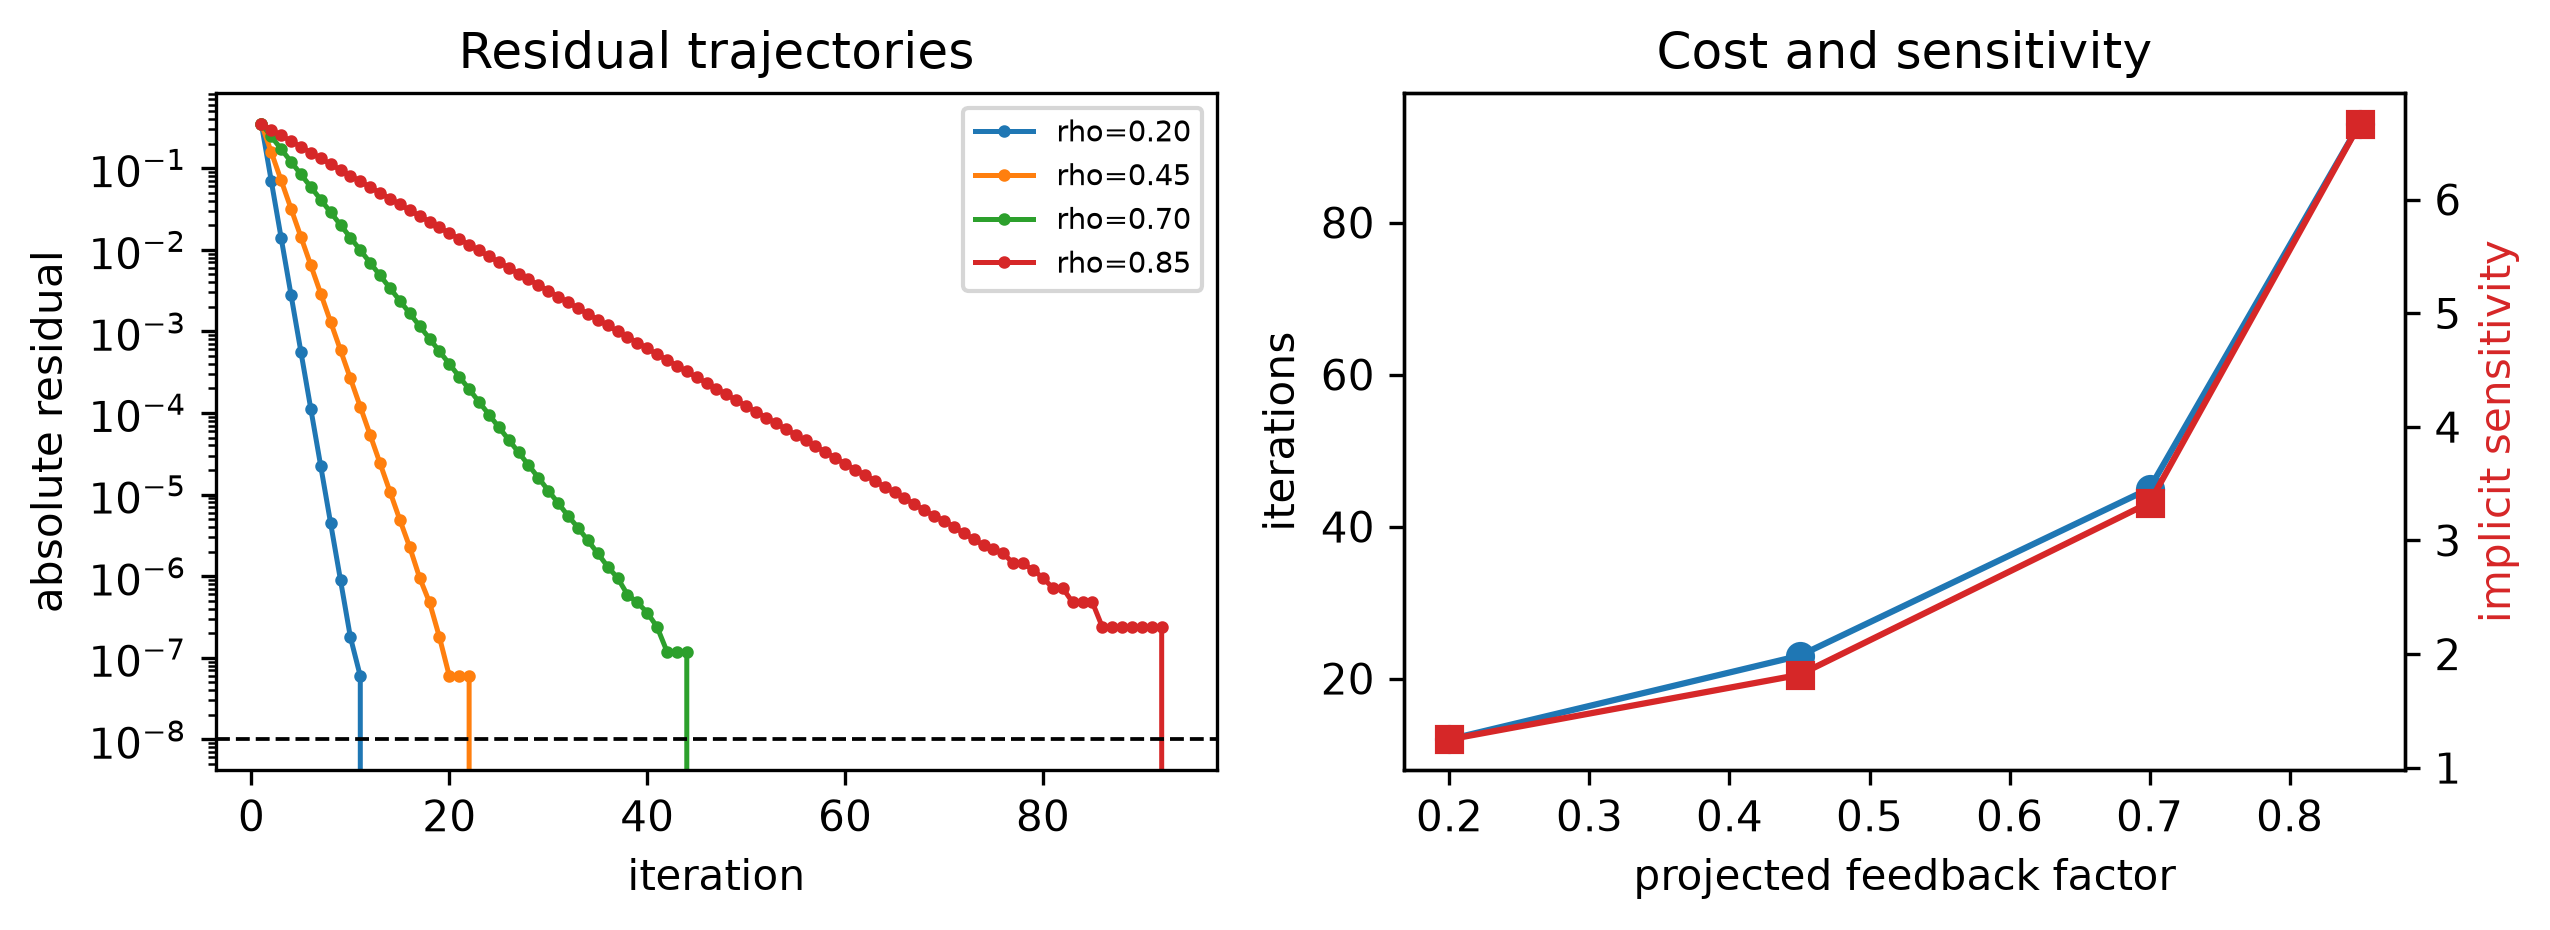

In [12]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('projected feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the projected feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | objective gap, feasibility residual, KKT residual, and gradient error |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | feasibility, domain projection, state shape, and optimality conditions |
| Scale sweep | Change one of variable count, constraint count, conditioning, and linear-solver budget at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How should I choose among the model families? | [Selecting Model Families](https://jseluis.github.io/silva-networks/learn/selecting-model-families/) |
| Where are several selected families run as scripts? | [Paper Family Cases](https://jseluis.github.io/silva-networks/examples/paper-family-cases/) |
| Which selector objects are public? | [Family Selection API](https://jseluis.github.io/silva-networks/api/families/) |
